In [1]:
import pandas as pd
import numpy as np

In [2]:
postings_db = pd.read_csv('../data/processed/postings_cleaned.csv')
# remove congress 86 from postings_db
postings_db = postings_db[postings_db['congress_number'] != 86]
postings_db.head()


,bioguide_id,chamber,congress_number,region_type,region_code,party,start_date,end_date
555,A000002,Representative,87,State,VA,Democrat,1961-01-03,1963-01-02
556,A000016,Representative,87,State,MS,Democrat,1961-01-03,1963-01-02
557,A000024,Representative,87,State,IN,Republican,1961-01-03,1963-01-02
558,A000052,Representative,87,State,NY,Democrat,1961-01-03,1963-01-02
559,A000054,Representative,87,State,NJ,Democrat,1961-01-03,1962-06-30


In [38]:
# set the datatype of start_date and end_date to datetime
postings_db['start_date'] = pd.to_datetime(postings_db['start_date'])
postings_db['end_date'] = pd.to_datetime(postings_db['end_date'])
postings_db.dtypes

bioguide_id                object
chamber                    object
congress_number             int64
region_type                object
region_code                object
party                      object
start_date         datetime64[ns]
end_date           datetime64[ns]
dtype: object

In [39]:
# Open profiles_db
profiles_db = pd.read_csv('../data/processed/profiles_cleaned.csv')
profiles_db['birth_date'] = pd.to_datetime(profiles_db['birth_date'])
profiles_db.dtypes

bioguide_id            object
first_name             object
last_name              object
birth_date     datetime64[ns]
dtype: object

In [5]:
# make a date range for congress sessions
# Earliest date in start_date column
# latest date in end_date column
start_date = postings_db['start_date'].min()
end_date = postings_db['end_date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
date_range

DatetimeIndex(['1961-01-03', '1961-01-04', '1961-01-05', '1961-01-06',
               '1961-01-07', '1961-01-08', '1961-01-09', '1961-01-10',
               '1961-01-11', '1961-01-12',
               ...
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30', '2024-12-31', '2025-01-01',
               '2025-01-02', '2025-01-03'],
              dtype='datetime64[ns]', length=23377, freq='D')

In [15]:
active_members = []
# define a function to make a list of active congress members on a given date
def get_active_members(date, postings_db):
    # active_members = []
    active_members = postings_db[(postings_db['start_date'] <= date) & (postings_db['end_date'] >= date)]
    return active_members['bioguide_id'].unique().tolist()

# Test the function
# get the number number of active members on 2000-01-01
active_members = get_active_members(pd.Timestamp('2000-01-01'), postings_db)
# show the length of the generated list
len(active_members)


['A000014', 'A000022', 'A000055', 'A000069', 'A000109', 'A000210', 'A000215', 'A000217', 'A000355', 'A000356', 'A000357', 'B000013', 'B000072', 'B000081', 'B000104', 'B000134', 'B000169', 'B000177', 'B000179', 'B000208', 'B000213', 'B000220', 'B000229', 'B000243', 'B000287', 'B000382', 'B000400', 'B000403', 'B000410', 'B000420', 'B000444', 'B000461', 'B000463', 'B000468', 'B000490', 'B000518', 'B000556', 'B000574', 'B000575', 'B000586', 'B000589', 'B000611', 'B000617', 'B000619', 'B000644', 'B000652', 'B000657', 'B000711', 'B000716', 'B000755', 'B000780', 'B000911', 'B000918', 'B000944', 'B000953', 'B000993', 'B000996', 'B001066', 'B001126', 'B001135', 'B001149', 'B001203', 'B001210', 'B001227', 'B001228', 'B001229', 'B001230', 'B001231', 'B001232', 'B001233', 'B001234', 'C000052', 'C000059', 'C000071', 'C000077', 'C000100', 'C000107', 'C000116', 'C000141', 'C000191', 'C000243', 'C000266', 'C000286', 'C000345', 'C000380', 'C000488', 'C000494', 'C000503', 'C000537', 'C000556', 'C000560'

In [19]:
# define a function to find the birth_date of a member given their bioguide_id
def get_birth_date(bioguide_id, profiles_db):
    birth_date = profiles_db.loc[profiles_db['bioguide_id'] == bioguide_id, 'birth_date'].iloc[0]
    return birth_date

# test the function
bioguide_id ='A000014'
birth_date =get_birth_date(bioguide_id, profiles_db)
print(birth_date)

AttributeError: 'Series' object has no attribute 'year'

In [7]:
'''
Use a series of for loops to calculate the average age thoughout the date range
- get_active_members(date, postings_db):
- get_birth_date(bioguide_id, profiles_db):
- calculate_age(birth_date, date):
- Save to a dataframe for visualization later
'''

# Define a date range for testing
date_range = pd.date_range(start='2000-01-01', end='2000-01-03', freq='D')

results = []

for date in date_range:
    daily_ages = []  # Initialize ONCE per date
    active_members = get_active_members(date, postings_db)
    for member in active_members:
        birth_date = get_birth_date(member, profiles_db)  # Single value
        age = calculate_age(birth_date, date)
        daily_ages.append(age)
    # Now calculate average for ALL members on this date
    average_age = round(np.mean(daily_ages), 3)
    results.append({
        'date': date,
        'average_age': average_age
    })

# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.head()

AttributeError: 'Series' object has no attribute 'year'

NOTE: Use box and whisker plot in a seperate viz. Maybe a stretch goal to do in Tableau

In [61]:
# Fully vectorized approach - much faster for large date ranges
# Merge postings with birth dates once
postings_with_birth = postings_db.merge(
    profiles_db[['bioguide_id', 'birth_date']], 
    on='bioguide_id'
)

# Explode date ranges to daily rows
postings_with_birth['date'] = postings_with_birth.apply(
    lambda row: pd.date_range(row['start_date'], row['end_date'], freq='D'), 
    axis=1
)
daily_data = postings_with_birth.explode('date')

# Calculate all ages at once (vectorized!)
daily_data['age'] = (daily_data['date'] - daily_data['birth_date']).dt.days / 365.25

# Group by date and calculate averages
results_df_vectorized = daily_data.groupby('date')['age'].agg([
    ('average_age', 'mean'),
    ('min_age', 'min'),
    ('max_age', 'max'),
    ('median_age', 'median'),
    ('std_dev', 'std'),
    ('q1_age', lambda x: x.quantile(0.25)),
    ('q3_age', lambda x: x.quantile(0.75))
]).round(3).reset_index()

results_df_vectorized.head()


,date,average_age,min_age,max_age,median_age,std_dev,q1_age,q3_age
0,1961-01-03,53.759,31.318,86.026,53.640,10.758,45.377,61.492
1,1961-01-04,53.764,31.321,86.029,53.697,10.767,45.355,61.500
2,1961-01-05,53.767,31.324,86.031,53.700,10.767,45.358,61.502
3,1961-01-06,53.770,31.326,86.034,53.703,10.767,45.361,61.505
4,1961-01-07,53.773,31.329,86.037,53.706,10.767,45.363,61.508


Text(0.5, 1.0, 'Average Age / Day')

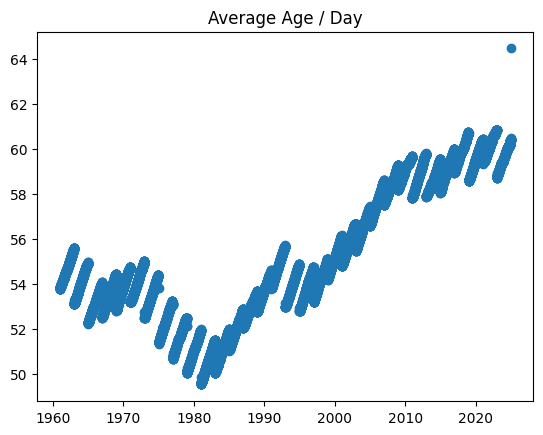

In [62]:
# Make a scatterplot with x-axis = date and y-axis = average_age
import matplotlib.pyplot as plt
y = results_df_vectorized['average_age']
x = results_df_vectorized['date']

plt.scatter(x, y)
plt.title('Average Age / Day')



In [63]:
# save results to a .csv
results_df_vectorized.to_csv('../data/processed/age_analysis.csv', index=False)